In [18]:
# Importação das bibliotecas utilizadas
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

print("PyTorch funcionando!")
print("Versão:", torch.__version__)

PyTorch funcionando!
Versão: 2.11.0+cpu


In [19]:
# Carregamento e preparação do dataset MNIST
# As imagens possuem 28 x 28 pixels
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

trainset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

trainloader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

testloader = DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

print("Dataset carregado!")
print("Imagens para treinamento:", len(trainset))
print("Imagens para teste:", len(testset))

Dataset carregado!
Imagens para treinamento: 60000
Imagens para teste: 10000


In [20]:
# Definição da rede neural
# Cada imagem possui 28 x 28 = 784 pixels
# A rede possui 10 saídas, correspondentes aos números de 0 a 9
class MLP(nn.Module):

    def __init__(self):
        super(MLP, self).__init__()

        self.fc1 = nn.Linear(28 * 28, 10)

    def forward(self, x):

        x = x.view(-1, 28 * 28)

        x = self.fc1(x)

        return x


model = MLP()

print(model)

MLP(
  (fc1): Linear(in_features=784, out_features=10, bias=True)
)


In [21]:
# Define a função utilizada para calcular o erro
criterion = nn.CrossEntropyLoss()

# Define o otimizador responsável por atualizar os pesos da rede
optimizer = optim.SGD(
    model.parameters(),
    lr=0.1
)

print("Função de perda e otimizador configurados!")

Função de perda e otimizador configurados!


In [22]:
# Treinamento da rede neural durante 3 épocas
for epoch in range(3):

    running_loss = 0.0

    for images, labels in trainloader:
        # Zera os gradientes anteriores
        optimizer.zero_grad()
        # Faz a previsão
        outputs = model(images)
        # Calcula o erro
        loss = criterion(outputs, labels)
        # Calcula os gradientes
        loss.backward()
        # Atualiza os pesos da rede
        optimizer.step()

        running_loss += loss.item()

    print(
        f"Época {epoch + 1}/3 - "
        f"Loss: {running_loss / len(trainloader):.4f}"
    )

Época 1/3 - Loss: 0.4786
Época 2/3 - Loss: 0.3373
Época 3/3 - Loss: 0.3147


In [23]:
# Avaliação do modelo no conjunto de teste
correct = 0
total = 0

with torch.no_grad():

    for images, labels in testloader:
        # Faz as previsões
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        # Conta quantas previsões estão corretas
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Acurácia: {accuracy:.2f}%")

Acurácia: 91.76%


In [24]:
# Função para realizar uma previsão em uma imagem individual
def inferencia(model, image):
    model.eval()

    with torch.no_grad():
        image = image.view(-1, 28 * 28)
        output = model(image)
        _, predicted = torch.max(output, 1)

    return predicted.item()

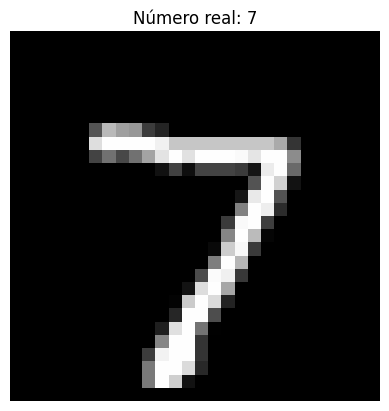

Número real: 7
Predição da rede: 7


In [25]:
# Teste da rede em uma imagem individual
import matplotlib.pyplot as plt

sample_image, label = testset[0]

plt.imshow(sample_image.squeeze(), cmap="gray")
plt.title(f"Número real: {label}")
plt.axis("off")
plt.show()

predicao = inferencia(model, sample_image)

print(f"Número real: {label}")
print(f"Predição da rede: {predicao}")